## LDA
### outline
- 简介
- 数学推导
- 优缺点
- sklearn实战

### 简介
线性判别是一种监督学习方法，用于分类也可以用于监督维度。它的核心思想找一个投影方向 (w)，把样本投影到这个方向上，使得不同类别的样本投影后尽可能分开，同时同一类别的样本尽可能集中。对于二分类问题，可以把样本投影为$z=w^Tx$，投影后将原来二维问题变成沿着w方向的一维问题

需要注意：

- Fisher LDA 的目标函数主要负责寻找“最有区分能力的方向”
- 真正做分类时，还需要确定一个分类阈值
- sklearn 中的 `LinearDiscriminantAnalysis` 不只是按照 Fisher 准则求 (w)，它还基于**高斯类条件分布 + 共享协方差矩阵 + Bayes 决策**建立线性分类器。
> todo 

### 数学推导
#### 1. 找到一个好的投影方向
假设现在有两个类别 $(C_1,C_2)$，它们的均值分别为：
$$
\mu_1=\frac{1}{n_1}\sum_{x_i\in C_1}x_i
$$
$$
\mu_2=\frac{1}{n_2}\sum_{x_i\in C_2}x_i
$$

把样本投影到 (w) 方向：
$$
z_i=w^Tx_i
$$


那么两个类别的均值投影以后分别为：

$$
\mu_1^*=w^T\mu_1
$$
$$
\mu_2^*=w^T\mu_2
$$
我们希望
1. 两个异类均值距离尽可能大
2. 同一个类别内部的样本尽可能集中
因此定义J(s)
$$
J(w)=
\frac{(\mu_1^*-\mu_2^*)^2}
{s_1^2+s_2^2}
$$
其中 $(s_i^2)$ 表示第 i 个类别投影后的类内散度：
$$
s_i^2=\sum_{x_j\in C_i}
(w^Tx_j-w^T\mu_i)^2
$$


#### 2. 把目标函数写成矩阵形式
分子：

$$
(\mu_1^*-\mu_2^*)^2
=
(w^T\mu_1-w^T\mu_2)^2
$$

整理得到：

$$
\left[w^T(\mu_1-\mu_2)\right]^2
=
w^T(\mu_1-\mu_2)(\mu_1-\mu_2)^Tw
$$

于是定义二分类情况下的类间散度矩阵：

$$
S_b=(\mu_1-\mu_2)(\mu_1-\mu_2)^T
$$

它描述的是**类别均值之间的差异**。

再看分母：

$$
s_1^2+s_2^2
=
\sum_{x_j\in C_1}
(w^T(x_j-\mu_1))^2
+
\sum_{x_j\in C_2}
(w^T(x_j-\mu_2))^2
$$

利用：

$$
(w^Ta)^2=w^Taa^Tw
$$

可以写成：

$$
w^T
\left[
\sum_{x_j\in C_1}(x_j-\mu_1)(x_j-\mu_1)^T+
\sum_{x_j\in C_2}(x_j-\mu_2)(x_j-\mu_2)^T
\right]w
$$

定义类内散度矩阵：

$$
S_w=
\sum_{x_j\in C_1}(x_j-\mu_1)(x_j-\mu_1)^T+
\sum_{x_j\in C_2}(x_j-\mu_2)(x_j-\mu_2)^T
$$

于是：

$$
J(w)=\frac{w^TS_bw}{w^TS_ww}
$$

这里有一个容易混淆的地方：

> $S_w$ 和通常统计学中除以 $n$ 得到的“协方差矩阵”并不完全一样。这里定义的是**类内散度矩阵**，没有除以样本数。




#### 3. 为什么只关心 w 的方向？
观察J(w)把投影向量w放大k被成kw后，还是没变化
$$J(kw) = \frac{(kw)^T S_b (kw)}{(kw)^T S_w (kw)} = \frac{k^2 w^T S_b w}{k^2 w^T S_w w} = J(w)$$
意味着J(w)的值与w的长度无关，只与方向有关。所以这里需要加一个限制得到唯一解，不是会有无穷个解(w是放向)。这是求极值问题，如果分母上加限制会方便求解比起分子上来说，这里引入约束$W^TS_wW=1$。这里的优化问题通过拉格朗日乘子法来求解([拉格朗日乘数](../Math/calculus/拉格朗日乘数.ipynb))
- 约束条件  $w^T S_w w = 1$
- 优化目标  $\max \ w^T S_b w$

构造拉格朗日乘子
$$L(w, \lambda) = w^T S_b w - \lambda (w^T S_w w - 1)$$
求解最佳w，先对其L求导让其等于0
$$\frac{\partial L}{\partial w} = 2 S_b w - 2 \lambda S_w w = 0$$
两边乘$S_w^{-1}$
$$S_w^{-1} S_b w = \lambda w$$
拆解$S_b w$：$S_b w = (\mu_1 - \mu_2)(\mu_1 - \mu_2)^Tw$可发现 $(\mu_1 - \mu_2)^Tw$是一个向量，然后在乘$(\mu_1 - \mu_2)$就成一个标量所以
$$S_b w = c (\mu_1 - \mu_2)$$
再带回原来式子
$$c (\mu_1 - \mu_2) = \lambda S_w w$$
$$w = \frac{c}{\lambda} S_w^{-1} (\mu_1 - \mu_2)$$
因为$\frac{c}{\lambda}$ 是个标量，LDA只关系w方向所以可以把它省去变成
$$w  \propto S_w^{-1} (\mu_1 - \mu_2)$$

> 理论推导中的 $S_w^{-1}$ 隐含了 $S_w$可逆的条件；实际数据中 $ S_w $ 可能奇异，因此工程实现通常会通过伪逆、正则化或 shrinkage 等方式处理
> - 伪逆 w=S^+(\mu_1-\mu_2)
> - 正则化 $S_w+\lambda I$

#### 4. 分类边界垂直与w投影方向

这里还有个问题，w是投影方向，也就是把数据样本压到那个方向上，而分类边界满足$w^Tx+b=0$，这个超平面的方向正式w，因此分类边界与w垂直。所以前面的目标函数是在找最佳投影方向w，而没直接给出截距b。

在 sklearn 的 LDA 分类器中，分类边界可以从高斯类条件分布和 Bayes 决策得到

> todo 后面在补

所以这里归纳一下，LDA主要做什么事情
1. 通过目标函数$J(w)=\frac{w^TS_bw}{w^TS_ww}$找到投影最佳方向
2. 在通过概率模型找到截距b
3. 结合上面求出的$w^Tx+b$得到最终投影线

In [1]:
import seaborn as sbn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
%matplotlib inline

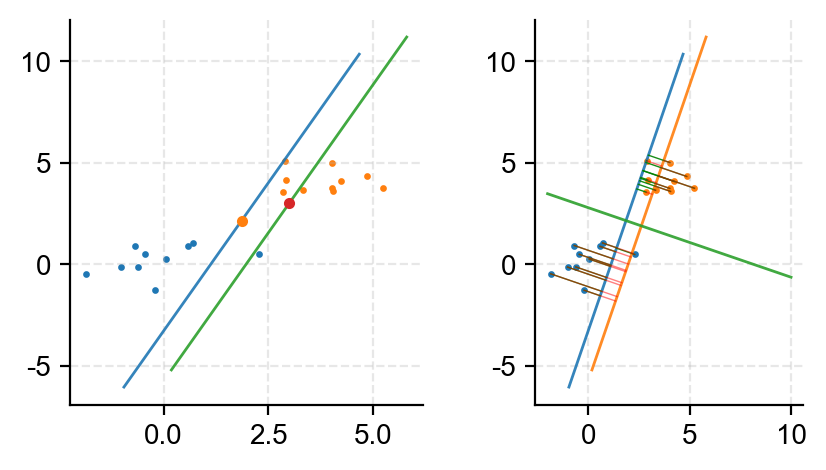

In [55]:
np.random.seed(40)
x_1=np.random.standard_normal(size=(10,2))
x_2=np.random.normal(4,0.8,size=(10,2))

X=np.row_stack([x_1,x_2])
y=np.row_stack([np.ones((10,1)),np.zeros((10,1))]).ravel()

lda=LinearDiscriminantAnalysis()

fig,axs=plt.subplots(1,2)

axs[0].scatter(x_1[:,0],x_1[:,1],s=2)
axs[0].scatter(x_2[:,0],x_2[:,1],s=2)
model=lda.fit(X,y)
w=model.coef_[0]
b=model.intercept_

#
mu=X.mean(axis=0)
wx_mu=np.array([mu[0]-w[0],mu[0]+w[0]])
wy_mu=np.array([mu[1]-w[1],mu[1]+w[1]])
axs[0].plot(wx_mu,wy_mu,linewidth=1,alpha=0.9)
axs[0].plot(*mu,marker='.')

r=(3,3)
wx_r=np.array([r[0]-w[0],r[0]+w[0]])
wy_r=np.array([r[1]-w[1],r[1]+w[1]])
axs[0].plot(wx_r,wy_r,linewidth=1,alpha=0.9)
axs[0].plot(*r,marker='.')



# 第二幅

axs[1].scatter(x_1[:,0],x_1[:,1],s=2)
axs[1].scatter(x_2[:,0],x_2[:,1],s=2)


#
mu=X.mean(axis=0)

wx_mu=np.array([mu[0]-w[0],mu[0]+w[0]])
wy_mu=np.array([mu[1]-w[1],mu[1]+w[1]])
axs[1].plot(wx_mu,wy_mu,linewidth=1,alpha=0.9)
axs[1].plot(wx_r,wy_r,linewidth=1,alpha=0.9)

x=np.linspace(-2,10)
y=-(w[0]/w[1])*x-b/w[1]

axs[1].plot(x,y,linewidth=1,alpha=0.9)



# 样本投影线,以过样本中心点为例
# 设过mu点直线参数p=mu+wt
# 样本点x_i它的垂直点x_p,再利用内积(x_i-x_p).Tw=0
# (x_i-(mu+wt)).Tw  t=(x_i-u)/w^2

t=(X-mu)@w/(w.T@w)
PMU=mu+w*(t.reshape(-1,1))

tr=(X-r)@w/(w.T@w)
PR=r+w*(tr.reshape(-1,1))
for xi,pu,pr in zip(X,PMU,PR):
    x_i,y_i=xi
  
    x_p,y_p=pu
    x_r,y_r=pr

    axs[1].plot((x_i,x_p),(y_i,y_p),color='green',lw=0.5,alpha=0.9)
    axs[1].plot((x_i,x_r),(y_i,y_r),color='red',lw=0.5,alpha=0.5)
axs[1].set_aspect('equal') # 会变形



上面这幅图，强调了J(w)求出w最佳投影方向，可以看蓝线和绿线就是w可视化，通过观察样本分布投影到直线上，各个样本点之间的差距并没有发生变化。也就是只要与w方向平行的直线都满足。另外第二张的绿线就是满足LDA异类样本分界线，斜率是-w[0]/w[1]，所以不好把投影方向和分类边界混成同一条直线，他们相互垂直的



<details>
  <summary><b>👉 数据投影线可视化</b></summary>
  以平行于投影过数据中心的点的直线为例，
  它的直线参数方程:

  $$p=\mu+wt$$

  t是标量，它表示在沿着w方向上的占比长度。$x_i $表示数据样本坐标，$x_p= \mu+wt$ 该数据样本投影到直线的坐标，$x_i-x_p$样本i的投影向量由内积公式可得
  
  $$
  (x_i-x_p)^Tw=0
  $$
  $$
  (x_i-(\mu+wt))^Tw=0
  $$
  $$
  (x_i-\mu)^Tw=w^Twt
  $$
  $$
  t=\frac{(x_i-\mu)^Tw}{w^Tw}
  $$
  
</details>

## 优缺点
1. 原理清晰，可解释性较强
LDA 的核心目标是让“类间分离、类内集中”，投影方向 w 也比较容易从几何角度解释
2. 既可以分类，也可以降维
通过 `transform()` 可以把原始特征投影到 LDA 判别空间
3. 小样本场景下通常比较有竞争力
相比一些复杂模型，LDA 参数数量相对少，训练速度快。在样本量不大、类别分布比较规整的问题上，往往是一个值得尝试的基线模型。
4. 有概率解释
LDA 不只是一个“找直线”的几何算法，还可以从高斯分布和 Bayes 决策的角度理解，并可以通过 `predict_proba()` 得到类别概率
5. 多分类天然支持
LDA 不只适用于二分类。对于 K 个类别，它可以寻找最多 K-1 个判别方向。


缺点
1. 对分布假设比较敏感
经典 LDA 假设：

$$
x|y=k\sim N(\mu_k,\Sigma)
$$

并且所有类别共享同一个协方差矩阵。

真实数据如果严重偏离这些假设，LDA 的效果可能下降。

2. 高维、小样本时协方差估计容易不稳定

当特征数量 p 很大，而样本数量 n 很小时，协方差矩阵可能接近奇异甚至不可逆。

3. 决策边界是线性的

LDA 最终得到的是线性分类边界。

如果真实类别之间的关系是明显的非线性结构，例如环形、复杂曲线，LDA 往往不如核 SVM、树模型等非线性模型。

实用的判断：

> **数据量不是特别巨大 + 特征数量适中 + 类别之间大致呈线性可分 + 数据分布没有严重违背高斯/共享协方差假设 → LDA 很值得作为 baseline。**

如果是：

- 明显非线性 → 考虑 SVM、树模型等；
- 高维小样本 → 重点考虑 shrinkage；
- 各类别协方差差异明显 → 可以比较 LDA 与 QDA；
- 主要目的是可视化/降维 → 重点看 `transform()`；
- 主要目的是分类 → 重点看验证集上的分类指标，而不是只看降维图。


## sklearn实战

sklearn使用
```python
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
```

主要参数

- solver: svd,lsqr,eigen
lsqr,eigen配合shrinkage改变原有不满足要求矩阵$S_w+\lambda I$ （$S_w可能不可逆$）

- shrinkage：0-1，auto
> $$\tilde{S}_w = (1 - \alpha)S_w + \alpha \frac{\text{Tr}(S_w)}{d} I$$

- priors 类别先验概率，关于分界线参数

- n_components 控制降维后的维度，K类别最多只有K-1

- store_covariance 和 covariance_estimator 是存储协方差矩阵$S_w$，solver=svd显式不保存(求解没用到协方差矩阵-做了优化)；covariance_estimator协方差估计器为了在数据质量不理想时，提供一套高级版本的协方差来计算
> LDA 有一个非常经典的底层假设：它假设所有类别的数据都服从高斯分布（正态分布），并且各个类别拥有相同的协方差矩阵（也就是形状相同、只是中心不同的椭球体）。


方法
- predict(X_test) 训练完成，得到预测类别
- predict_proba(X_test) 看类别概率
- transform() 降维

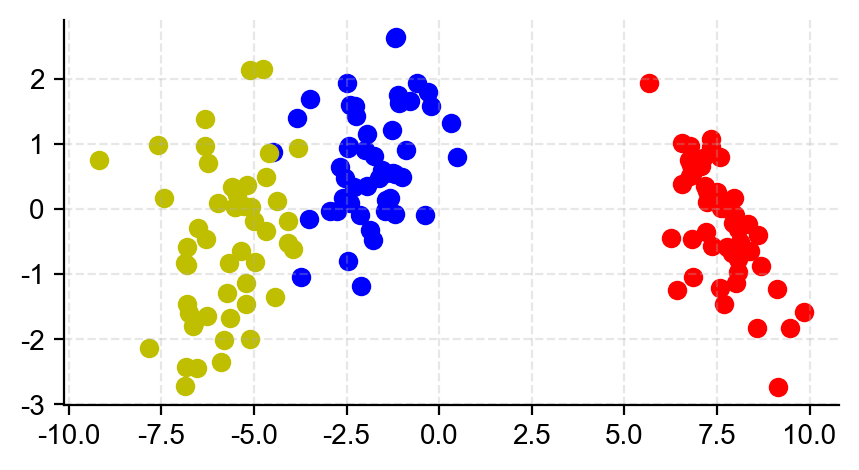

In [ ]:
from sklearn.datasets import load_iris
iris=load_iris()

X=iris['data']
y=iris['target']

lda=LinearDiscriminantAnalysis(n_components=2)

X_lda=lda.fit_transform(X,y)

colors=['r','b','y']
for zclass,color in enumerate(colors):
    plt.scatter(X_lda[y==zclass,0],X_lda[y==zclass,1],c=color)

<Axes: ylabel='Density'>

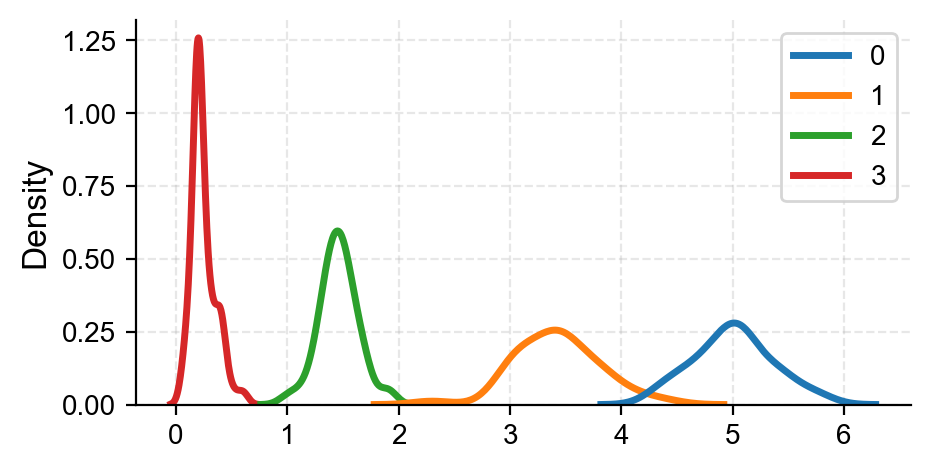

In [16]:
sbn.kdeplot(X[y==0])

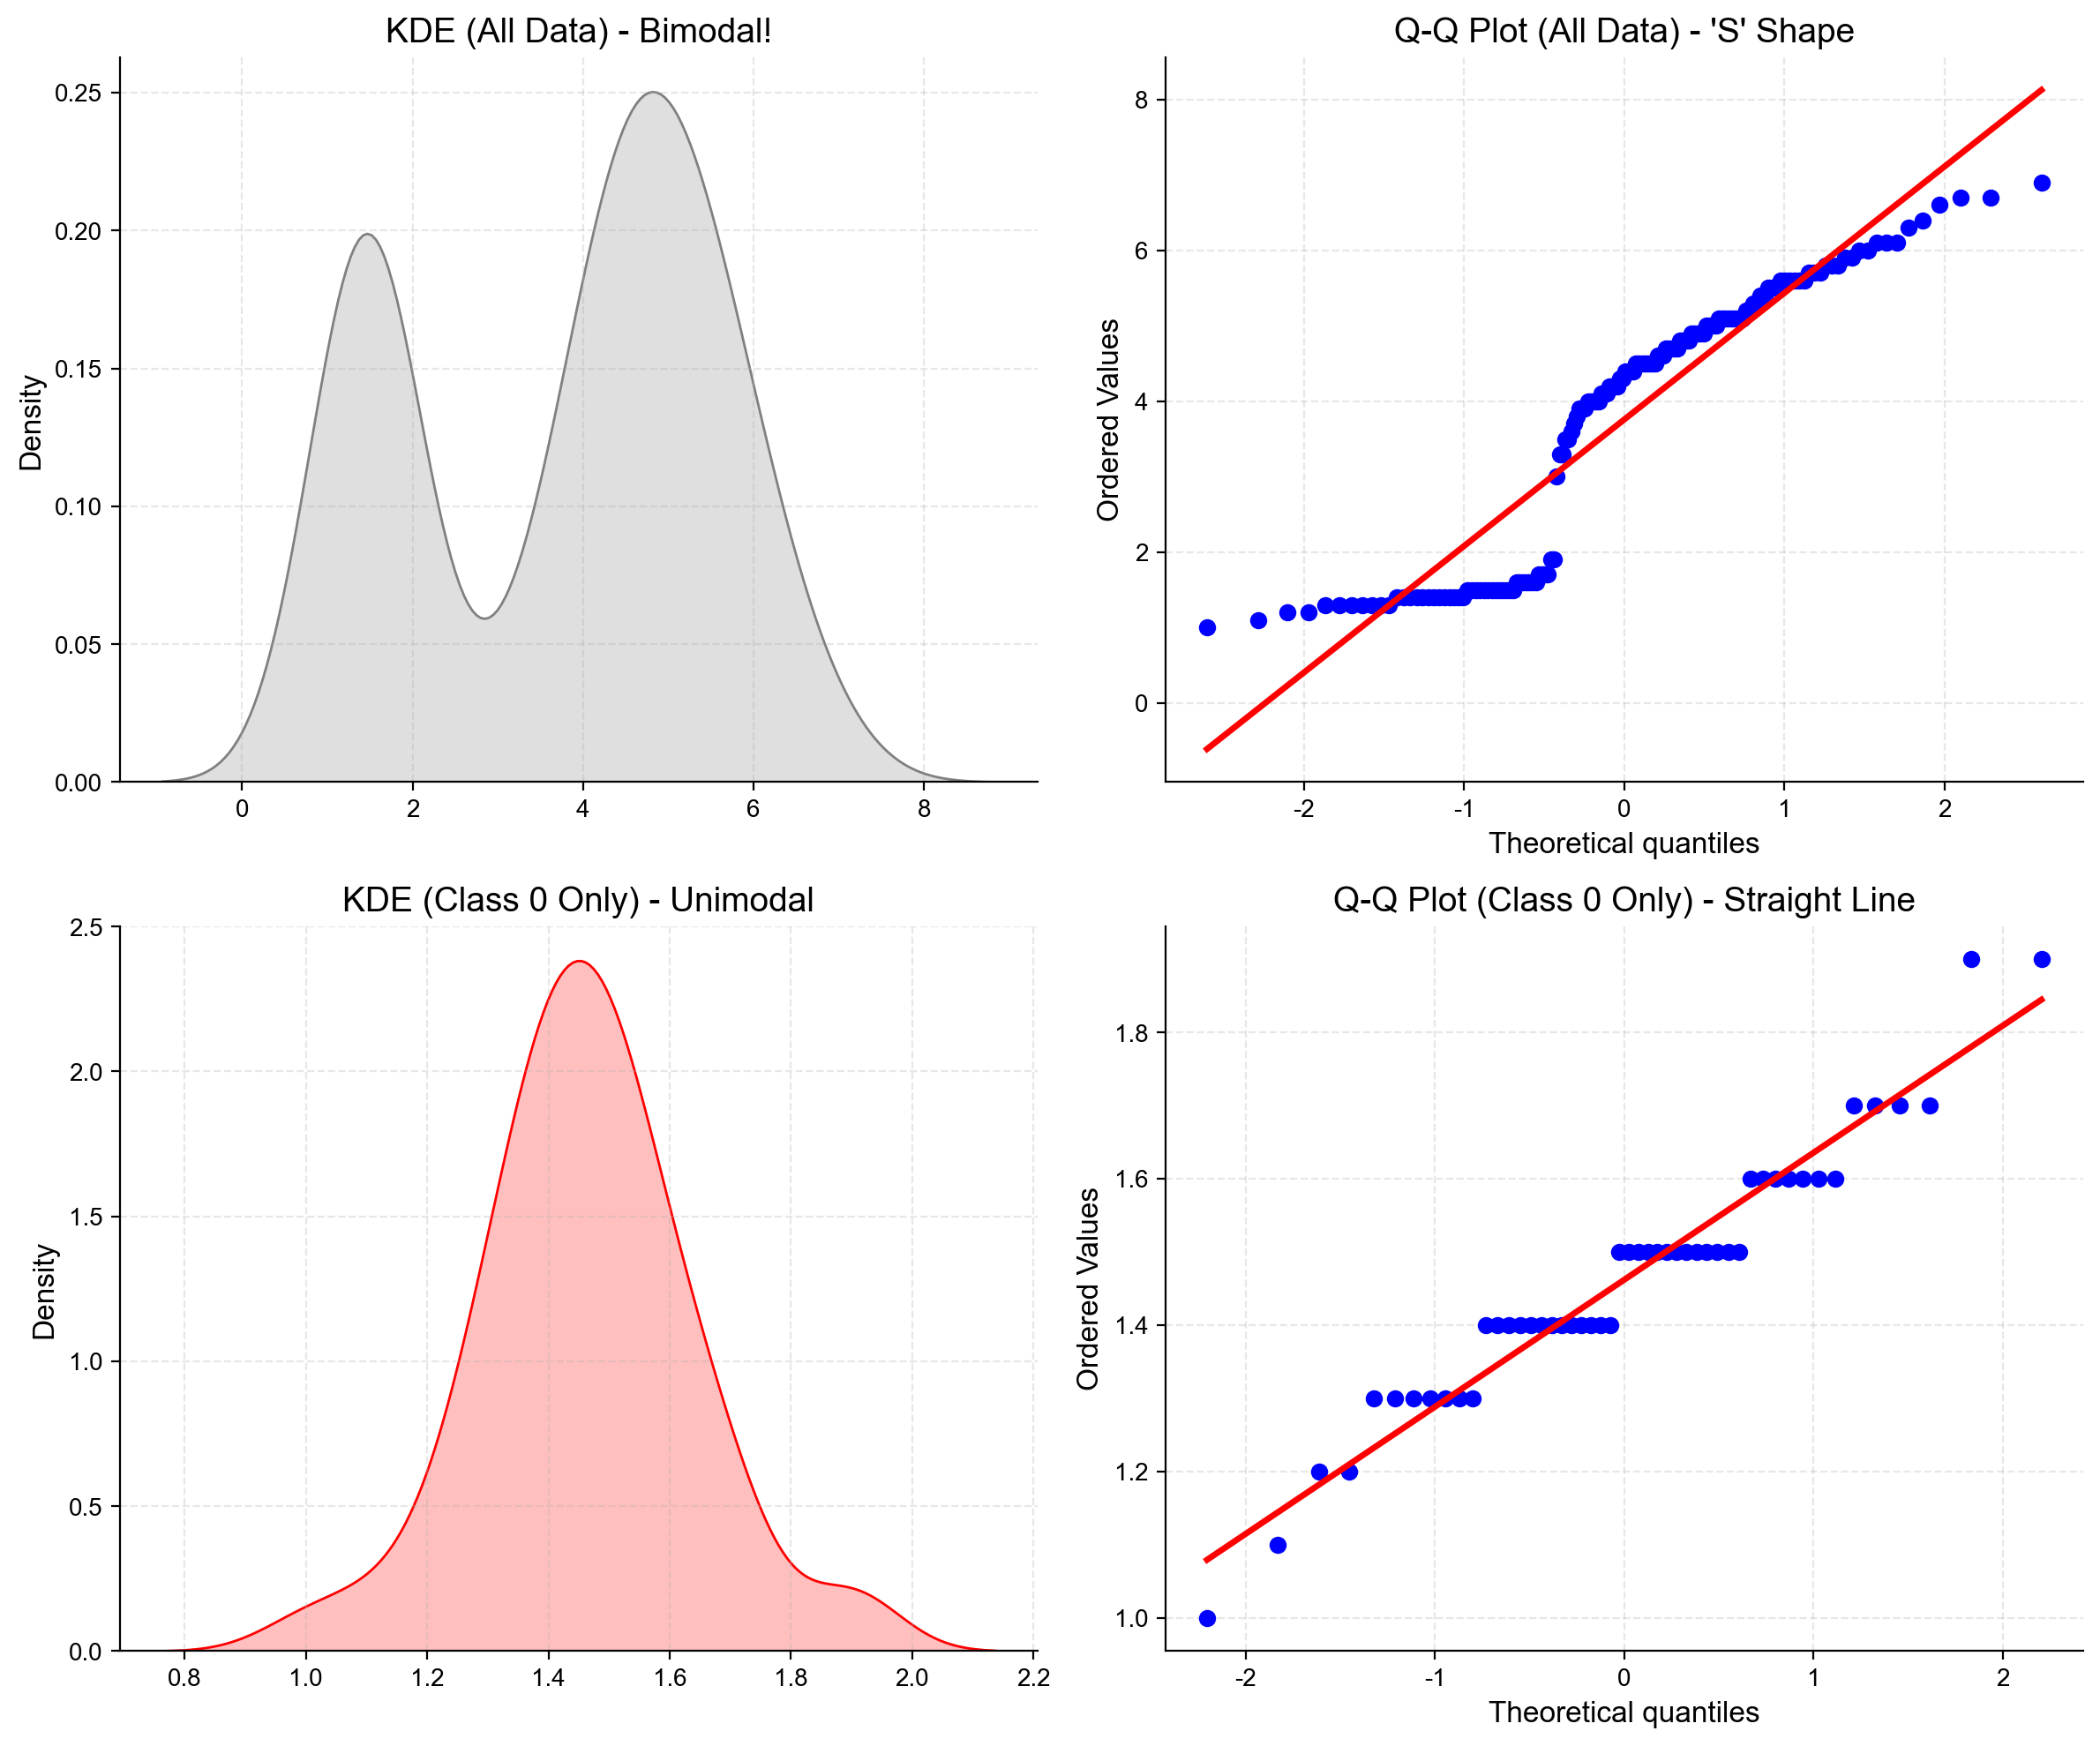

In [18]:
import scipy.stats as stats
feature_idx = 2  
feature_data = X[:, feature_idx]
plt.figure(figsize=(12, 10))

# ==========================================
# 1. 错误视角：把所有数据混在一起看（会出现双峰）
# ==========================================
plt.subplot(2, 2, 1)
sbn.kdeplot(feature_data, fill=True, color="gray")
plt.title("KDE (All Data) - Bimodal!")

plt.subplot(2, 2, 2)
stats.probplot(feature_data, dist="norm", plot=plt)
plt.title("Q-Q Plot (All Data) - 'S' Shape")

# ==========================================
# 2. 正确视角：只看类别 0 (Setosa) 的特征分布
# ==========================================
# 利用布尔索引筛选出类别 0 的数据
class_0_data = feature_data[y == 0]

plt.subplot(2, 2, 3)
sbn.kdeplot(class_0_data, fill=True, color="red")
plt.title("KDE (Class 0 Only) - Unimodal")

plt.subplot(2, 2, 4)
stats.probplot(class_0_data, dist="norm", plot=plt)
plt.title("Q-Q Plot (Class 0 Only) - Straight Line")

plt.tight_layout()